In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
accuracy_score,
classification_report,
confusion_matrix
)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dd = pd.read_csv('/content/drive/MyDrive/titanic.csv')

In [6]:

dd.shape

(891, 12)

In [7]:
dd.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
dd.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [9]:
dd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
dd.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [11]:
dd.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
dd["Age"].fillna(dd["Age"].median(), inplace=True)

dd["Embarked"].fillna(
dd["Embarked"].mode()[0],inplace=True)

dd["Cabin"].fillna("Unknown",inplace=True)

print(dd.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


/tmp/ipykernel_463/328679425.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dd["Age"].fillna(dd["Age"].median(), inplace=True)
/tmp/ipykernel_463/328679425.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [13]:
print("Duplicates =",dd.duplicated().sum())

dd.drop_duplicates(inplace=True)

Duplicates = 0


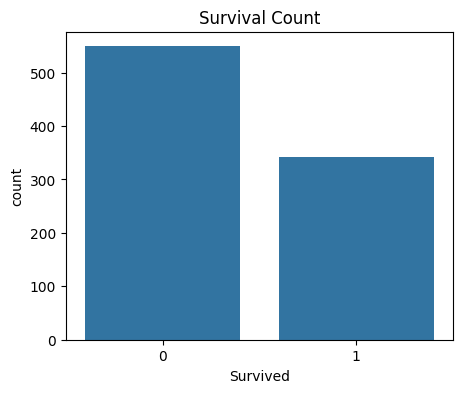

In [14]:
plt.figure(figsize=(5,4))

sns.countplot(
x="Survived",data=dd)

plt.title("Survival Count")
plt.show()

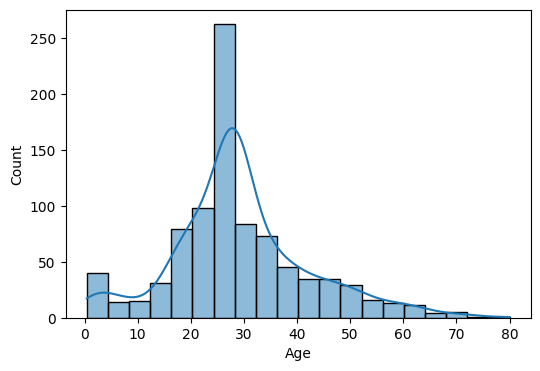

In [15]:
plt.figure(figsize=(6,4))

sns.histplot(dd["Age"],bins=20,kde=True)

plt.show()

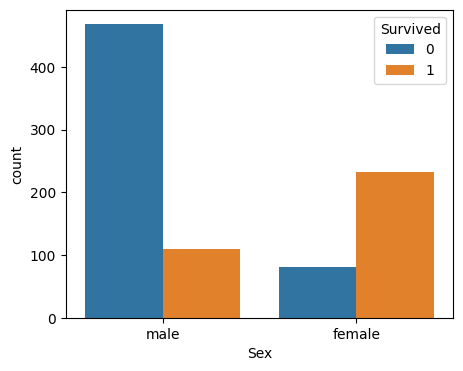

In [16]:
plt.figure(figsize=(5,4))
sns.countplot(x="Sex",hue="Survived",data=dd)
plt.show()

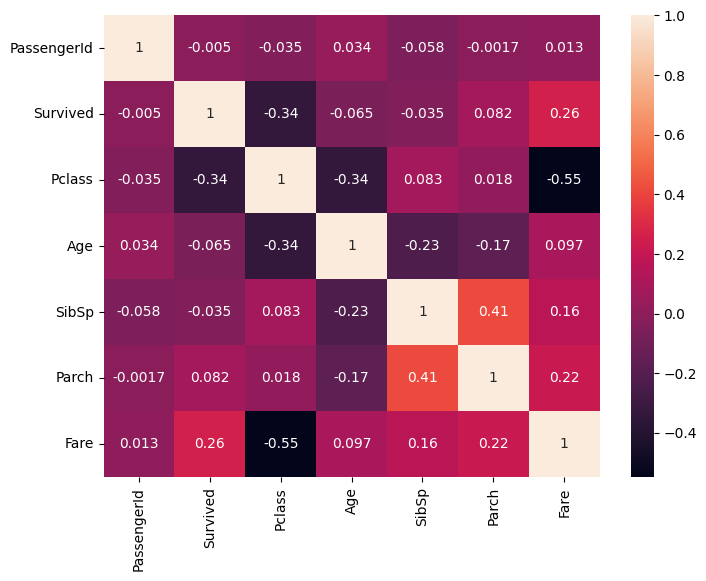

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(dd.corr(numeric_only=True),annot=True)

plt.show()


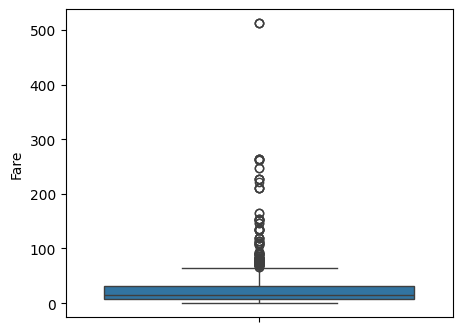

In [18]:
plt.figure(figsize=(5,4))

sns.boxplot(y=dd["Fare"])

plt.show()

In [19]:
Q1=dd["Fare"].quantile(.25)
Q3=dd["Fare"].quantile(.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

data=dd[
(dd["Fare"]>=lower)
&
(dd["Fare"]<=upper)
]

print(dd.shape)

(891, 12)


In [20]:
encoder=LabelEncoder()

columns=[
"Sex",
"Embarked",
"Cabin",
"Ticket",
"Name"
]

for col in columns:
    data[col]=encoder.fit_transform(
    data[col].astype(str)
    )

/tmp/ipykernel_463/3200554526.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col]=encoder.fit_transform(
/tmp/ipykernel_463/3200554526.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col]=encoder.fit_transform(
/tmp/ipykernel_463/3200554526.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/

In [21]:
X=data.drop("Survived",axis=1)
y=data["Survived"]
print(X.head())

   PassengerId  Pclass  Name  Sex   Age  SibSp  Parch  Ticket     Fare  Cabin  \
0            1       3    93    1  22.0      1      0     495   7.2500     87   
2            3       3   298    0  26.0      0      0     621   7.9250     87   
3            4       1   230    0  35.0      1      0      41  53.1000     35   
4            5       3    14    1  35.0      0      0     444   8.0500     87   
5            6       3   481    1  28.0      0      0     253   8.4583     87   

   Embarked  
0         2  
2         2  
3         2  
4         2  
5         1  


In [22]:
X_train,X_test,y_train,y_test=\
train_test_split(X,y,test_size=0.20,random_state=42)
print(X_train.shape)
print(X_test.shape)

(620, 11)
(155, 11)


In [23]:
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)


RandomForestClassifier(random_state=42)

In [24]:
pred=model.predict(X_test)
print(pred)

[0 0 1 0 0 0 0 1 1 0 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0
 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 1 0 0 0 0 0 1 1 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 1 1 0 0 0 0 0 1 1
 1 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 1 1 1 0 1 0 1 0 0 0 1 0 1 0 0 1 0 0 0 1 1
 0 0 0 0 1 0 1]


In [25]:
acc=accuracy_score(y_test,pred)
print("Accuracy =",acc)
print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))

Accuracy = 0.7935483870967742
              precision    recall  f1-score   support

           0       0.79      0.89      0.84        95
           1       0.79      0.63      0.70        60

    accuracy                           0.79       155
   macro avg       0.79      0.76      0.77       155
weighted avg       0.79      0.79      0.79       155

[[85 10]
 [22 38]]


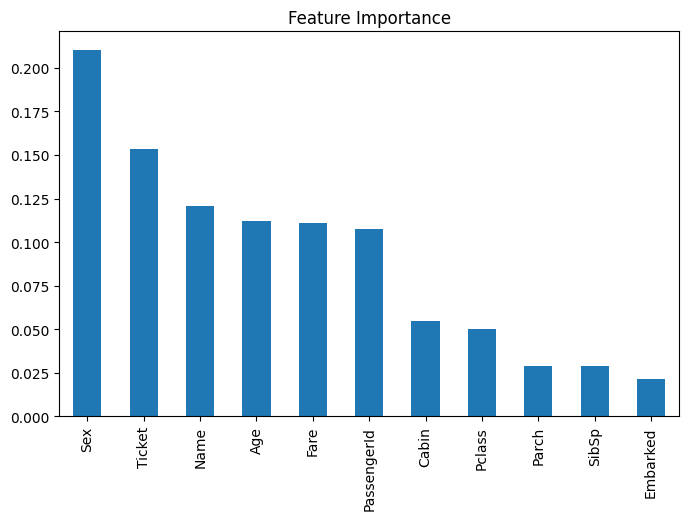

In [26]:
importance=pd.Series(model.feature_importances_,index=X.columns)
importance.sort_values(ascending=False).plot(kind="bar",figsize=(8,5))
plt.title("Feature Importance")
plt.show()

In [27]:
print("Random Forest Accuracy:",acc*100)

Random Forest Accuracy: 79.35483870967742
